In [19]:
import yfinance as yf
import numpy as np
import datetime
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
start = datetime.datetime(2023, 11, 1)
end = datetime.datetime(2024, 11, 1)


onehour_step = 1
fourhour_step = 4
oneday_step = 24


coins = ("BTC-USD", "ETH-USD", "USDT-USD", "SOL-USD", "XRP-USD")

In [4]:
onehour_dict = {}
fourhour_dict = {}
oneday_dict = {}

for coin in coins:
    onehour_dict[coin] = (
        yf.Ticker(coin).history(interval="1h", start=start, end=end).Close
    )
    fourhour_dict[coin] = onehour_dict[coin][::fourhour_step]
    oneday_dict[coin] = (
        yf.Ticker(coin).history(interval="1d", start=start, end=end).Close
    )

In [9]:
onehour_dataframe = pd.DataFrame(onehour_dict).dropna()
fourhour_dataframe = pd.DataFrame(fourhour_dict)
oneday_dataframe = pd.DataFrame(oneday_dict)

In [12]:
stats = {}

In [18]:
for coin in onehour_dataframe.columns:
    print(f"{coin} Stationary Probability : {(1 - adfuller(onehour_dataframe[coin])[1])*100:.2f}")

BTC-USD Stationary Probability : 58.68
ETH-USD Stationary Probability : 73.19
USDT-USD Stationary Probability : 100.00
SOL-USD Stationary Probability : 81.00
XRP-USD Stationary Probability : 97.74


As we discovered, BTC-USD is non-stationary.

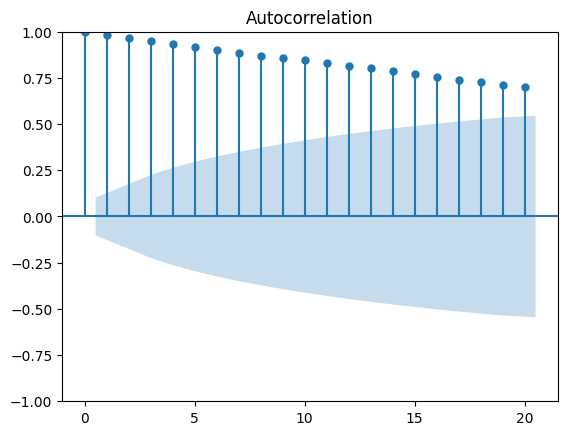

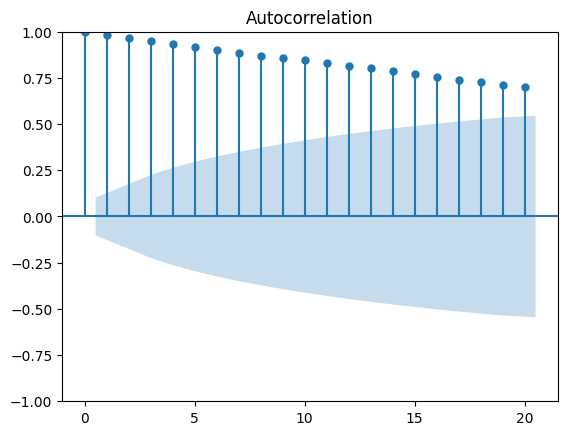

In [43]:
plot_acf(oneday_dataframe['BTC-USD'], lags=20)

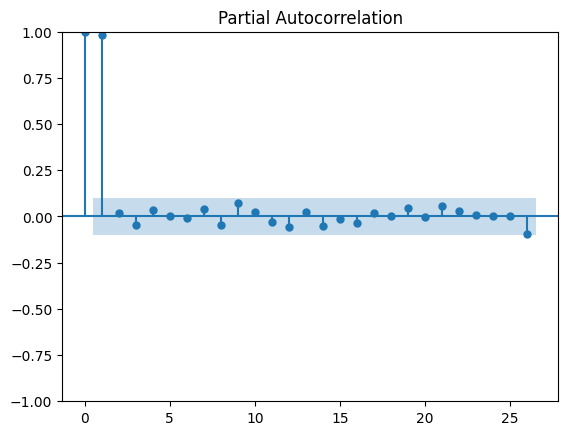

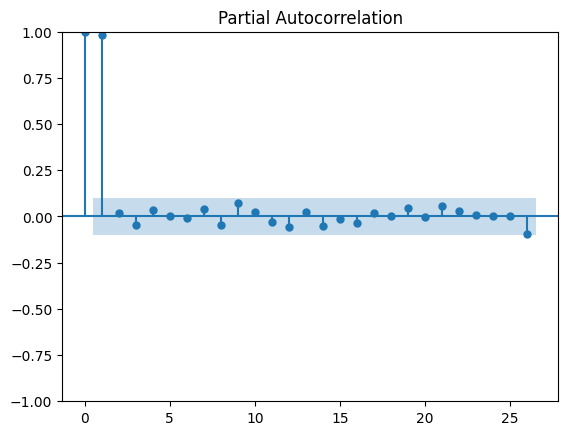

In [44]:
plot_pacf(oneday_dataframe['BTC-USD'], method="ywm")